# Monte Carlo Stock Price Simulator

**Author:** Riddhi Raut | B.S. Data Science, Honors College @ University of Georgia

This notebook estimates a stock's drift and volatility from 5 years of real historical data, then simulates 10,000 possible price paths over the next year using Geometric Brownian Motion (GBM). From the simulated distribution, it estimates downside risk metrics including 95% Value-at-Risk and probability of loss.

**Why GBM?** It's the standard baseline model for stock prices (it underlies the Black-Scholes model). It assumes returns are normally distributed with constant drift and volatility. Real markets violate these assumptions (fat tails, volatility clustering), which is discussed in the conclusions.

In [ ]:
# Install yfinance (needed in Colab)
!pip install yfinance -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

np.random.seed(42)  # reproducibility

## 1. Pull historical data

[*********************100%***********************]  1 of 1 completed


1256 trading days of data
Latest close: $204.71


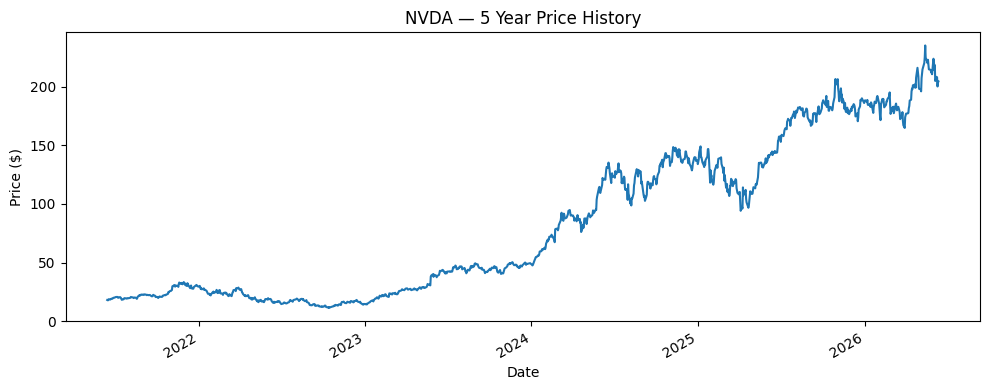

In [ ]:
TICKER = "NVDA"

prices = yf.download(TICKER, period="5y", auto_adjust=True)["Close"].squeeze().dropna()

print(f"{len(prices)} trading days of data")
print(f"Latest close: ${prices.iloc[-1]:.2f}")

prices.plot(figsize=(10, 4), title=f"{TICKER} — 5 Year Price History")
plt.ylabel("Price ($)")
plt.tight_layout()
plt.show()

## 2. Estimate drift and volatility from log returns

GBM is parameterized by annualized drift and volatility. We estimate both from daily **log returns** and annualize using 252 trading days.

Annualized drift (mu):       48.87%
Annualized volatility (sigma): 51.37%


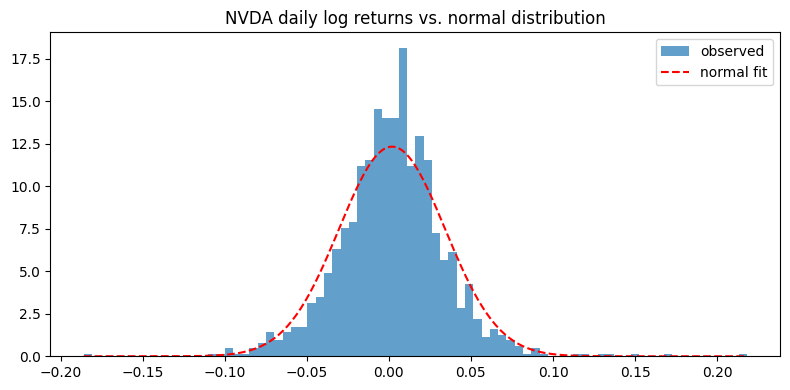


Excess kurtosis: 3.81 (0 = normal; higher = fatter tails)


In [ ]:
log_returns = np.log(prices / prices.shift(1)).dropna()

mu = log_returns.mean() * 252          # annualized drift
sigma = log_returns.std() * np.sqrt(252)  # annualized volatility
S0 = prices.iloc[-1]                   # starting price = latest close

print(f"Annualized drift (mu):       {mu:.2%}")
print(f"Annualized volatility (sigma): {sigma:.2%}")

# sanity check: are daily log returns roughly normal?
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(log_returns, bins=80, density=True, alpha=0.7, label="observed")
x = np.linspace(log_returns.min(), log_returns.max(), 300)
normal_pdf = (1 / (log_returns.std() * np.sqrt(2 * np.pi))) * \
             np.exp(-0.5 * ((x - log_returns.mean()) / log_returns.std())**2)
ax.plot(x, normal_pdf, "r--", label="normal fit")
ax.set_title(f"{TICKER} daily log returns vs. normal distribution")
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nExcess kurtosis: {log_returns.kurtosis():.2f} (0 = normal; higher = fatter tails)")

## 3. Simulate 10,000 price paths

The GBM solution gives the price at each step. Using that, we simulate 252 daily steps (one trading year) for 10,000 independent paths, fully vectorized in NumPy.

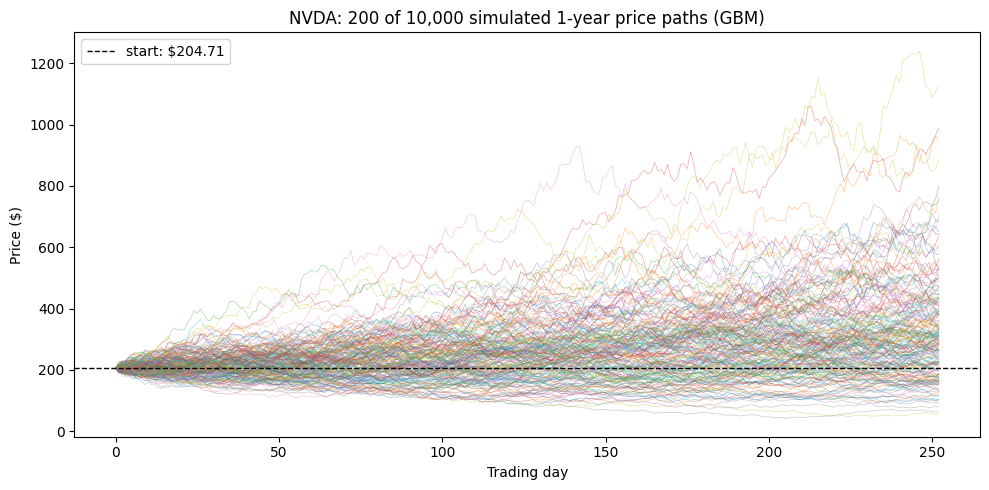

In [ ]:
N_SIMS = 10_000
N_STEPS = 252      # one trading year
T = 1.0            # in years
dt = T / N_STEPS

Z = np.random.standard_normal((N_SIMS, N_STEPS))
increments = (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z
paths = S0 * np.exp(np.cumsum(increments, axis=1))
paths = np.hstack([np.full((N_SIMS, 1), S0), paths])  # prepend starting price

# plot a sample of paths
plt.figure(figsize=(10, 5))
plt.plot(paths[:200].T, linewidth=0.5, alpha=0.4)
plt.axhline(S0, color="black", linestyle="--", linewidth=1, label=f"start: ${S0:.2f}")
plt.title(f"{TICKER}: 200 of {N_SIMS:,} simulated 1-year price paths (GBM)")
plt.xlabel("Trading day")
plt.ylabel("Price ($)")
plt.legend()
plt.tight_layout()
plt.show()

## 4. Risk metrics from the simulated distribution

--- NVDA: 1-year outlook from 10,000 simulations ---
Median price:            $291.04
90% price interval:      $124.09 to $672.97
Mean return:             61.96%
Probability of loss:     24.1%
95% VaR:                 -39.38%  (5% chance of losing more than this)
95% CVaR (exp. shortfall): -50.23%  (avg loss in the worst 5% of outcomes)


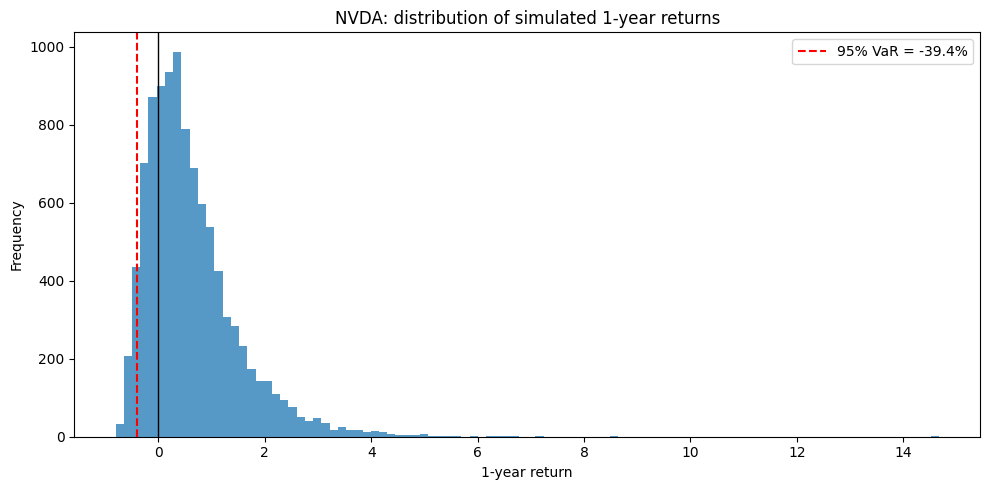

In [ ]:
final_prices = paths[:, -1]
final_returns = final_prices / S0 - 1

var_95 = np.percentile(final_returns, 5)   # 95% Value-at-Risk
cvar_95 = final_returns[final_returns <= var_95].mean()  # expected shortfall
prob_loss = (final_returns < 0).mean()
p5, p50, p95 = np.percentile(final_prices, [5, 50, 95])

print(f"--- {TICKER}: 1-year outlook from {N_SIMS:,} simulations ---")
print(f"Median price:            ${p50:,.2f}")
print(f"90% price interval:      ${p5:,.2f} to ${p95:,.2f}")
print(f"Mean return:             {final_returns.mean():.2%}")
print(f"Probability of loss:     {prob_loss:.1%}")
print(f"95% VaR:                 {var_95:.2%}  (5% chance of losing more than this)")
print(f"95% CVaR (exp. shortfall): {cvar_95:.2%}  (avg loss in the worst 5% of outcomes)")

plt.figure(figsize=(10, 5))
plt.hist(final_returns, bins=100, alpha=0.75)
plt.axvline(var_95, color="red", linestyle="--", label=f"95% VaR = {var_95:.1%}")
plt.axvline(0, color="black", linewidth=1)
plt.title(f"{TICKER}: distribution of simulated 1-year returns")
plt.xlabel("1-year return")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

## 5. Conclusions and limitations

**What this model does well:** turns 5 years of historical behavior into a full probability distribution of outcomes, which is far more informative than a single point forecast. VaR and expected shortfall are the same metrics risk desks report daily.

**Where it breaks:** The excess kurtosis computed in Section 2 is well above 0 for most stocks, meaning extreme moves happen more often than the normal distribution predicts. GBM therefore *understates* tail risk.